# Mandatory Practical Work 01: CNNs on iCoSimal V3 Dataset

**MSE FTP Deep Learning**

## Group Members
- Student 1: Marcos, Costa
- Student 2: Jose Pablo, Muñoz
- Student 3: Artemii, Ponomarenko

## Mandatory Objectives
- Start from simple CNN architectures and progressively increase their complexity to show the benefit of depth.
- Show the importance of hyperparameter tuning.
- Show models that overfit and underfit and explain the reasons for that.
- Experiment with regularization techniques.
- Experiment with different optimization algorithms (e.g., Adam, RMSprop) and compare their performance.

## Optional Objectives
-  Perform error analysis to identify common misclassifications
- Use tools to monitor the training process and analyze the training and validation curves (e.g., Tensorboard, Weights & Biases)
- Use advanced architectures (e.g., ResNet, DenseNet) and compare their performance with simpler architectures
- Experiment with data augmentation techniques to improve model generalization (e.g., random cropping, horizontal flipping, color jittering)

## Table of Contents

1. [Setup and Data Loading](#section-1-setup-and-data-loading)
2. [Benefit of Depth](#section-2-benefit-of-depth)
3. [Overfitting vs Underfitting](#section-3-overfitting-vs-underfitting)
4. [Regularization Techniques](#section-4-regularization-techniques)
5. [Optimizer Comparison](#section-5-optimizer-comparison)
6. [Hyperparameter Tunning](#section-6-hyperparameter-tunning)
7. [Data Augmentation](#section-7-data-augmentation)
8. [Error Analysis](#section-8-error-analysis)
9. [ResNet Comparison](#section-9-resnet-comparison)
10. [Conclusions](#section-10-conclusions)

---
## Section 1. Setup and Data Loading

If you don't have access to a GPU use the [Colab Extension](https://marketplace.visualstudio.com/items?itemName=Google.colab) for VS Code

### Install dependencies

In [ ]:
%pip install torch torchvision matplotlib wandb

### Setup Weights & Biases

In [ ]:
import wandb
wandb.login()

### Download the dataset

Download the iCoSimal V3 dataset from [here](https://drive.switch.ch/index.php/s/NTiYe8mamrgys3M)

If you are working locally, extract it as:

```
data/
├── train/
│   ├── cat/
│   ├── chicken/
│   └── ... (10 classes)
└── validate/
    ├── cat/
    └── ...
```

If you are using the Colab extension, you can upload the zip file to Drive and mount it to the session

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip -q /content/drive/MyDrive/data.zip -d /content

### Import Libraries and Check for GPU

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os

device = torch.device('cuda' if torch.cuda.is_available() else 
                      'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


### Configuration

In [2]:
# Dataset paths
DATA_ROOT = "./data"
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
VAL_DIR = os.path.join(DATA_ROOT, "validate")

# Image size - 64x64 for fast experiments, 224x224 for final results
IMG_SIZE = 64

# Training defaults
BATCH_SIZE = 64
NUM_WORKERS = 2
NUM_CLASSES = 10

# W&B Configuration
WANDB_PROJECT = "icosimal-cnn"
WANDB_ENTITY = None

# Class names for reference
CLASS_NAMES = ['cat', 'chicken', 'cow', 'dog', 'elephant', 
               'horse', 'rabbit', 'sheep', 'squirrel', 'zebra']

### Data Loader

In [3]:
def get_data_loaders(img_size=IMG_SIZE, batch_size=BATCH_SIZE, augment=False, train_fraction=1.0):
    """Create train and validation data loaders."""
    
    # Base transforms
    normalize = transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
    
    if augment:
        train_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomApply([transforms.RandomRotation(15)], p=0.3),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            normalize
        ])
    else:
        train_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            normalize
        ])
    
    val_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        normalize
    ])
    
    train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
    val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_transform)
    
    if train_fraction < 1.0:
        subset_size = max(1, int(len(train_dataset) * train_fraction))
        indices = torch.randperm(len(train_dataset))[:subset_size].tolist()
        train_dataset = Subset(train_dataset, indices)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, 
                              shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, 
                            shuffle=False, num_workers=NUM_WORKERS)
    
    return train_loader, val_loader, train_dataset, val_dataset

Training samples: 24000
Validation samples: 6000


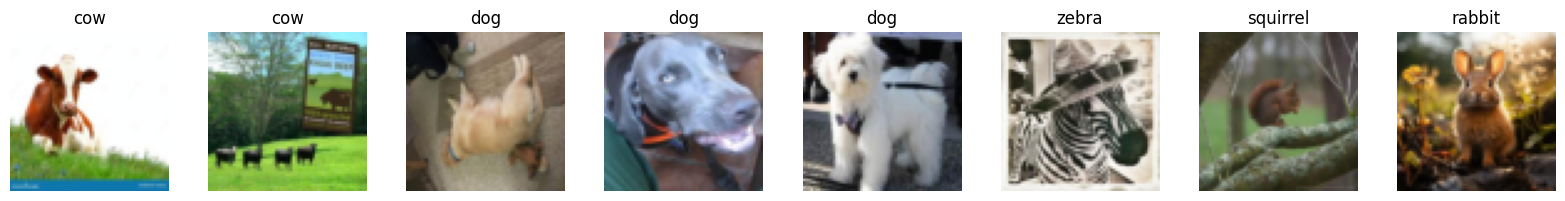

In [6]:
# Test data loading
train_loader, val_loader, train_dataset, val_dataset = get_data_loaders()
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Visualize some samples
def show_samples(dataset, n=8):
    fig, axes = plt.subplots(1, n, figsize=(16, 2))
    for i in range(n):
        idx = np.random.randint(len(dataset))
        img, label = dataset[idx]
        # Denormalize for display
        img = img.permute(1, 2, 0).numpy()
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)
        axes[i].imshow(img)
        axes[i].set_title(CLASS_NAMES[label])
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

show_samples(train_dataset)

### Training Utilities with W&B Integration

In [4]:
def train_epoch(model, loader, criterion, optimizer, device, l1_lambda=0.0):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        if l1_lambda > 0:
            l1_penalty = sum(param.abs().sum() for param in model.parameters())
            loss = loss + l1_lambda * l1_penalty
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return running_loss / total, 100. * correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate the model."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return running_loss / total, 100. * correct / total


def get_working_dir():
    """Return the base working directory for local or Colab runs."""
    try:
        import google.colab
        colab_drive_root = "/content/drive/MyDrive"
        if os.path.exists(colab_drive_root):
            project_dir = os.path.join(colab_drive_root, "DeepLearning_practical_1")
            os.makedirs(project_dir, exist_ok=True)
            return project_dir
        print("Google Drive is not mounted; saving to temporary Colab storage.")
        return "/content"
    except Exception:
        return os.getcwd()


def train_model(model, train_loader, val_loader, config, device=device, wandb=True):
    """
    Full training loop with W&B logging.
    
    config dict should contain:
        - experiment: experiment name
        - model_name: model architecture name
        - epochs: number of epochs
        - lr: learning rate
        - optimizer: 'adam', 'sgd', 'sgd_momentum', 'rmsprop'
        - weight_decay: L2 regularization (default 0)
        - momentum: momentum for SGD (default 0.9)
        - l1_lambda: L1 regularization (default 0)
    """
    
    model_name = config.get('model_name', 'unnamed_model')
    
    if wandb:
        run = wandb.init(
            project=WANDB_PROJECT,
            entity=WANDB_ENTITY,
            name=f"{config.get('experiment', 'unnamed_experiment')}_{model_name}",
            config=config,
            reinit=True
    )
    
    criterion = nn.CrossEntropyLoss()
    opt_name = config.get('optimizer', 'adam').lower()
    lr = config.get('lr', 0.001)
    epochs = config.get('epochs', 10)
    weight_decay = config.get('weight_decay', 0)
    momentum = config.get('momentum', 0.9)
    l1_lambda = config.get('l1_lambda', 0.0)
    
    if opt_name == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif opt_name == 'sgd_momentum':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    elif opt_name == 'rmsprop':
        optimizer = optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    model = model.to(device)
    
    # Log model architecture
    if wandb:
        wandb.watch(model, log='all', log_freq=100)
    
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, l1_lambda=l1_lambda)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        # Log metrics to W&B
        if wandb:
            wandb.log({
                'epoch': epoch + 1,
                'train/loss': train_loss,
                'train/accuracy': train_acc,
                'val/loss': val_loss,
                'val/accuracy': val_acc,
                'train_val_gap': train_acc - val_acc,
                'learning_rate': optimizer.param_groups[0]['lr']
            })
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")
    
    # Log final summary metrics
    if wandb:
        wandb.summary['best_val_accuracy'] = max(history['val_acc'])
        wandb.summary['final_val_accuracy'] = history['val_acc'][-1]
        wandb.summary['final_train_accuracy'] = history['train_acc'][-1]
        wandb.summary['final_gap'] = history['train_acc'][-1] - history['val_acc'][-1]
        wandb.finish()
    
    # Save model locally or to Drive
    model_dir = os.path.join(get_working_dir(), "saved_models")
    os.makedirs(model_dir, exist_ok=True)
    model_path = os.path.join(model_dir, f"{model_name}.pt")
    torch.save({
        'model_state_dict': model.state_dict(),
        'config': config,
        'history': history
    }, model_path)
    print(f"Model saved to {model_path}")
    
    return history


def load_history(model_name):
    model_path = os.path.join(get_working_dir(), "saved_models", f"{model_name}.pt")
    if os.path.exists(model_path):
        checkpoint = torch.load(model_path, map_location=device)
        return checkpoint.get('history')
    raise FileNotFoundError(f"Model not found at {model_path}")


def plot_history(history, title="Training History"):
    """Plot training curves locally."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(history['train_loss'], label='Train')
    ax1.plot(history['val_loss'], label='Validation')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_ylim(0, max(max(history['train_loss']), max(history['val_loss'])) * 1.05 if history['train_loss'] and history['val_loss'] else 1)
    ax1.set_title('Loss')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(history['train_acc'], label='Train')
    ax2.plot(history['val_acc'], label='Validation')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_ylim(0, 100)
    ax2.set_title('Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def compare_histories(histories, labels, title="Model Comparison"):
    """Compare multiple training runs locally."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    for hist, label in zip(histories, labels):
        ax1.plot(hist['val_loss'], label=label)
        ax2.plot(hist['val_acc'], label=label)
    
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Validation Loss')
    ax1.set_title('Validation Loss Comparison')
    ax1.legend()
    ax1.grid(True)
    
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Validation Accuracy (%)')
    ax2.set_title('Validation Accuracy Comparison')
    ax2.legend()
    ax2.grid(True)
    
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def summarize_histories(histories, labels):
    """Print summary statistics for each training history."""

    print('\n' + '=' * 90)
    print('SUMMARY')
    print('=' * 90)

    for i, hist in enumerate(histories):
        label = labels[i]
        val_acc = hist['val_acc']
        train_acc = hist['train_acc']

        best_train = float(max(train_acc)) 
        final_train = float(train_acc[-1])
        best_val = float(max(val_acc))
        final_val = float(val_acc[-1])
        final_gap = final_train - final_val

        print(
            f'{label:30} | Best Val: {best_val:6.2f}% | Final Val: {final_val:6.2f}% | Best Train: {best_train:6.2f}% | Final Train: {final_train:6.2f}% | Final Gap: {final_gap:6.2f}%'
        )

---
## Section 2: Benefit of Depth

In this section we will explore the benefit of depth by comparing a shallow net with 1 convolutional layer, a medium net with 3 convolutional layers and a deep net with 5 convolutional layers 

### Architectures

In [9]:
class ShallowCNN(nn.Module):
    """1 convolutional layer"""
    def __init__(self, num_classes, img_size):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        feat_size = img_size // 2
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * feat_size * feat_size, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )
    
    def forward(self, x):
        return self.classifier(self.features(x))


class MediumCNN(nn.Module):
    """3 convolutional layers"""
    def __init__(self, num_classes, img_size):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        feat_size = img_size // 8
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * feat_size * feat_size, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        return self.classifier(self.features(x))


class DeepCNN(nn.Module):
    """5 convolutional layers"""
    def __init__(self, num_classes, img_size):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        feat_size = img_size // 32
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * feat_size * feat_size, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        return self.classifier(self.features(x))

### Train and Evaluate

In [29]:
train_loader, val_loader, _, _ = get_data_loaders(img_size=IMG_SIZE)

depth_models = [
    ("Shallow CNN Overfitting", ShallowCNN(num_classes=NUM_CLASSES, img_size=IMG_SIZE)),
    ("Medium CNN Overfitting", MediumCNN(num_classes=NUM_CLASSES, img_size=IMG_SIZE)),
    ("Deep CNN Overfitting", DeepCNN(num_classes=NUM_CLASSES, img_size=IMG_SIZE)),
]

depth_histories = []
for name, model in depth_models:
    print(f"\n--- Training {name} ---")
    
    config = {
        'experiment': 'Depth Comparison',
        'model_name': name,
        'epochs': 20,
    }
    
    history = train_model(model, train_loader, val_loader, config, wandb=False)
    depth_histories.append(history)


--- Training Shallow CNN Overfitting ---
Epoch 1/20 | Train Loss: 1.9738, Acc: 29.52% | Val Loss: 1.7379, Acc: 39.73%
Epoch 2/20 | Train Loss: 1.6467, Acc: 42.83% | Val Loss: 1.6423, Acc: 43.92%
Epoch 3/20 | Train Loss: 1.4997, Acc: 48.39% | Val Loss: 1.6339, Acc: 43.25%
Epoch 4/20 | Train Loss: 1.3911, Acc: 52.27% | Val Loss: 1.6154, Acc: 44.03%
Epoch 5/20 | Train Loss: 1.2921, Acc: 55.34% | Val Loss: 1.6261, Acc: 44.23%
Epoch 6/20 | Train Loss: 1.2198, Acc: 58.16% | Val Loss: 1.6379, Acc: 44.65%
Epoch 7/20 | Train Loss: 1.1312, Acc: 61.42% | Val Loss: 1.7791, Acc: 43.52%
Epoch 8/20 | Train Loss: 1.0558, Acc: 64.00% | Val Loss: 1.7530, Acc: 44.28%
Epoch 9/20 | Train Loss: 0.9832, Acc: 66.55% | Val Loss: 1.7714, Acc: 44.00%
Epoch 10/20 | Train Loss: 0.9189, Acc: 68.52% | Val Loss: 1.8333, Acc: 44.05%
Epoch 11/20 | Train Loss: 0.8532, Acc: 70.58% | Val Loss: 1.9325, Acc: 43.52%
Epoch 12/20 | Train Loss: 0.7932, Acc: 72.92% | Val Loss: 1.9879, Acc: 42.97%
Epoch 13/20 | Train Loss: 0.730

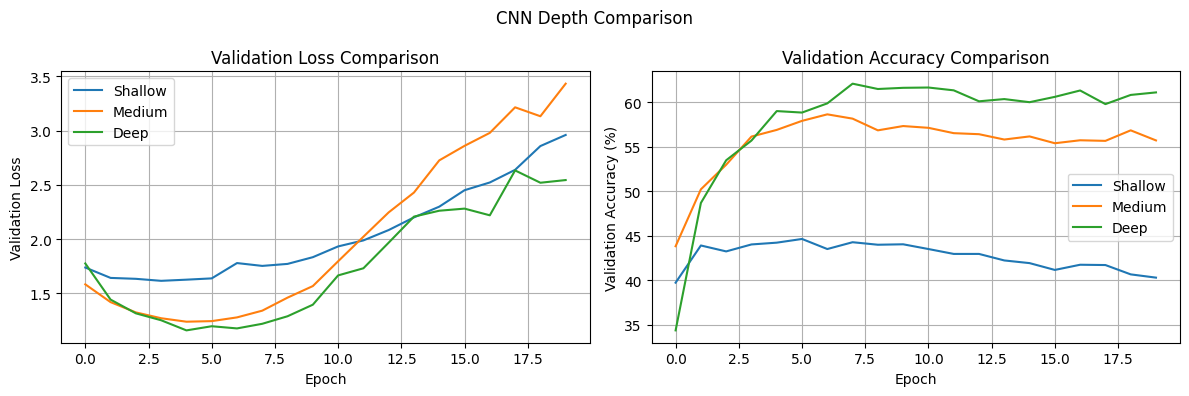

In [7]:
# Visualize depth comparison
if "depth_histories" not in globals():
    depth_histories = [load_history("Shallow CNN Overfitting"), 
                       load_history("Medium CNN Overfitting"), 
                       load_history("Deep CNN Overfitting")]

compare_histories(depth_histories, ["Shallow", "Medium", "Deep"], "CNN Depth Comparison")

### Depth Analysis

As expected, adding more convolutional layers consistently improves performance. ShallowCNN tops out at around 37.4% validation accuracy which is not surprising given that a single conv layer simply doesn't have enough capacity to tell apart 10 different animal classes. MediumCNN jumps to 59%, which shows that the extra layers are genuinely helping the network pick up more meaningful features. DeepCNN pushes this a bit further to ~62%, though the gap over Medium is smaller, suggesting we're starting to hit diminishing returns from depth alone.

One thing worth noting is that both Medium and Deep start overfitting pretty clearly after around epoch 5–7 validation loss keeps climbing even as accuracy stays somewhat flat. Medium is the worst offender here, with the loss shooting up to ~3.6 by the end, while Deep stays more controlled at ~2.6. This makes sense given that none of the three models have any regularisation in place.

## Section 2b: The Importance of Hyperparameter Tuning

In this section well explore the importance of hyperparameter tunning on CNNs. We'll use the MediumCNN and the DeepCNN to explore different parameters and assess their impact on learning.

Previously we saw that both MediumCNN and DeepCNN suffer from diverging validation loss with default settings (BATCH_SIZE = 64) where training loss drops while validation loss climbs, a clear sign that the default hyperparameters are not well-suited to these models. This provides a great opportunity to look at how tuning the learning rate and batch size changes convergence behaviour.


In [15]:
MODELS_TO_TUNE = [
    ("Medium", lambda: MediumCNN(num_classes=NUM_CLASSES, img_size=IMG_SIZE)),
    ("Deep",   lambda: DeepCNN(num_classes=NUM_CLASSES,   img_size=IMG_SIZE)),
]

## B1: Learning Rate Exploration (batch size fixed at default)

In [17]:

FIXED_BATCH_SIZE = 64

LR_SWEEP = [0.01, 0.001, 0.0001]

lr_results   = {}
lr_histories = []
lr_labels    = []

for model_name, model_fn in MODELS_TO_TUNE:
    for lr in LR_SWEEP:
        run_name = f"{model_name} | LR={lr}"
        print(f"\n--- {run_name} ---")

        train_loader, val_loader, _, _ = get_data_loaders(
            img_size=IMG_SIZE, batch_size=FIXED_BATCH_SIZE
        )

        config = {
            'experiment': 'LR Sweep',
            'model_name': run_name,
            'epochs': 20,
            'lr': lr,
            'batch_size': FIXED_BATCH_SIZE,
        }

        history = train_model(model_fn(), train_loader, val_loader, config, wandb=False)

        lr_results[run_name] = {
            'model': model_name, 'lr': lr,
            'best_val_acc':    max(history['val_acc']),
            'final_train_acc': history['train_acc'][-1],
            'final_val_acc':   history['val_acc'][-1],
        }
        lr_histories.append(history)
        lr_labels.append(run_name)

# pick best LR per model for use in B2
best_lr = {
    m: max(
        [(k, v) for k, v in lr_results.items() if v['model'] == m],
        key=lambda x: x[1]['best_val_acc']
    )[1]['lr']
    for m, _ in MODELS_TO_TUNE
}
print("\nBest LR per model:", best_lr)


--- Medium | LR=0.01 ---
Epoch 1/20 | Train Loss: 2.3184, Acc: 9.74% | Val Loss: 2.3031, Acc: 10.00%
Epoch 2/20 | Train Loss: 2.3036, Acc: 9.87% | Val Loss: 2.3030, Acc: 10.00%
Epoch 3/20 | Train Loss: 2.3038, Acc: 9.64% | Val Loss: 2.3037, Acc: 10.00%
Epoch 4/20 | Train Loss: 2.3038, Acc: 9.75% | Val Loss: 2.3033, Acc: 10.00%
Epoch 5/20 | Train Loss: 2.3036, Acc: 9.72% | Val Loss: 2.3029, Acc: 10.00%
Epoch 6/20 | Train Loss: 2.3038, Acc: 9.60% | Val Loss: 2.3029, Acc: 10.00%
Epoch 7/20 | Train Loss: 2.3038, Acc: 9.72% | Val Loss: 2.3033, Acc: 10.00%
Epoch 8/20 | Train Loss: 2.3038, Acc: 9.89% | Val Loss: 2.3034, Acc: 10.00%
Epoch 9/20 | Train Loss: 2.3037, Acc: 9.99% | Val Loss: 2.3031, Acc: 10.00%
Epoch 10/20 | Train Loss: 2.3037, Acc: 9.83% | Val Loss: 2.3030, Acc: 10.00%
Epoch 11/20 | Train Loss: 2.3038, Acc: 9.86% | Val Loss: 2.3031, Acc: 10.00%
Epoch 12/20 | Train Loss: 2.3035, Acc: 9.95% | Val Loss: 2.3035, Acc: 10.00%
Epoch 13/20 | Train Loss: 2.3036, Acc: 9.86% | Val Loss: 2.

## B2: Batch Size Exploration (best LR from B1 fixed) 

In [18]:
BS_SWEEP = [16, 32, 64]

bs_results   = {}
bs_histories = []
bs_labels    = []

for model_name, model_fn in MODELS_TO_TUNE:
    lr = best_lr[model_name]
    for bs in BS_SWEEP:
        run_name = f"{model_name} | BS={bs}"
        print(f"\n--- {run_name} (LR={lr}) ---")

        train_loader, val_loader, _, _ = get_data_loaders(
            img_size=IMG_SIZE, batch_size=bs
        )

        config = {
            'experiment': 'BS Sweep',
            'model_name': run_name,
            'epochs': 20,
            'lr': lr,
            'batch_size': bs,
        }

        history = train_model(model_fn(), train_loader, val_loader, config, wandb=False)

        bs_results[run_name] = {
            'model': model_name, 'batch_size': bs,
            'best_val_acc':    max(history['val_acc']),
            'final_train_acc': history['train_acc'][-1],
            'final_val_acc':   history['val_acc'][-1],
        }
        bs_histories.append(history)
        bs_labels.append(run_name)

# pick best batch size per model for use in B3
best_bs = {
    m: max(
        [(k, v) for k, v in bs_results.items() if v['model'] == m],
        key=lambda x: x[1]['best_val_acc']
    )[1]['batch_size']
    for m, _ in MODELS_TO_TUNE
}
print("\nBest BS per model:", best_bs)


--- Medium | BS=16 (LR=0.001) ---
Epoch 1/20 | Train Loss: 1.7491, Acc: 37.88% | Val Loss: 1.4969, Acc: 46.95%
Epoch 2/20 | Train Loss: 1.3562, Acc: 53.19% | Val Loss: 1.3101, Acc: 53.90%
Epoch 3/20 | Train Loss: 1.1686, Acc: 59.67% | Val Loss: 1.2542, Acc: 56.40%
Epoch 4/20 | Train Loss: 1.0038, Acc: 65.37% | Val Loss: 1.2132, Acc: 58.18%
Epoch 5/20 | Train Loss: 0.8516, Acc: 70.57% | Val Loss: 1.2825, Acc: 56.53%
Epoch 6/20 | Train Loss: 0.6955, Acc: 76.04% | Val Loss: 1.4176, Acc: 57.35%
Epoch 7/20 | Train Loss: 0.5434, Acc: 80.72% | Val Loss: 1.5108, Acc: 57.90%
Epoch 8/20 | Train Loss: 0.4254, Acc: 85.19% | Val Loss: 1.6846, Acc: 57.07%
Epoch 9/20 | Train Loss: 0.3167, Acc: 88.83% | Val Loss: 1.9903, Acc: 57.12%
Epoch 10/20 | Train Loss: 0.2587, Acc: 91.12% | Val Loss: 2.1248, Acc: 57.33%
Epoch 11/20 | Train Loss: 0.2077, Acc: 92.86% | Val Loss: 2.5368, Acc: 55.55%
Epoch 12/20 | Train Loss: 0.1747, Acc: 93.88% | Val Loss: 2.8934, Acc: 56.43%
Epoch 13/20 | Train Loss: 0.1647, Acc:

## B3: Combined best LR + best BS 

In [19]:
combined_results   = {}
combined_histories = []
combined_labels    = []

for model_name, model_fn in MODELS_TO_TUNE:
    lr = best_lr[model_name]
    bs = best_bs[model_name]
    run_name = f"{model_name} | LR={lr} BS={bs} (tuned)"
    print(f"\n--- {run_name} ---")

    train_loader, val_loader, _, _ = get_data_loaders(
        img_size=IMG_SIZE, batch_size=bs
    )

    config = {
        'experiment': 'Combined Best HP',
        'model_name': run_name,
        'epochs': 20,
        'lr': lr,
        'batch_size': bs,
    }

    history = train_model(model_fn(), train_loader, val_loader, config, wandb=False)

    combined_results[run_name] = {
        'model': model_name, 'lr': lr, 'batch_size': bs,
        'best_val_acc':    max(history['val_acc']),
        'final_train_acc': history['train_acc'][-1],
        'final_val_acc':   history['val_acc'][-1],
    }
    combined_histories.append(history)
    combined_labels.append(run_name)


--- Medium | LR=0.001 BS=32 (tuned) ---
Epoch 1/20 | Train Loss: 1.7878, Acc: 36.41% | Val Loss: 1.5342, Acc: 46.02%
Epoch 2/20 | Train Loss: 1.4257, Acc: 50.33% | Val Loss: 1.3840, Acc: 51.50%
Epoch 3/20 | Train Loss: 1.2284, Acc: 57.42% | Val Loss: 1.3315, Acc: 54.25%
Epoch 4/20 | Train Loss: 1.0673, Acc: 62.91% | Val Loss: 1.2519, Acc: 57.28%
Epoch 5/20 | Train Loss: 0.9122, Acc: 68.60% | Val Loss: 1.3141, Acc: 57.23%
Epoch 6/20 | Train Loss: 0.7637, Acc: 73.31% | Val Loss: 1.3291, Acc: 58.15%
Epoch 7/20 | Train Loss: 0.6035, Acc: 78.81% | Val Loss: 1.4263, Acc: 58.10%
Epoch 8/20 | Train Loss: 0.4578, Acc: 83.98% | Val Loss: 1.5904, Acc: 55.90%
Epoch 9/20 | Train Loss: 0.3346, Acc: 88.54% | Val Loss: 1.8312, Acc: 56.48%
Epoch 10/20 | Train Loss: 0.2459, Acc: 91.57% | Val Loss: 2.1771, Acc: 56.07%
Epoch 11/20 | Train Loss: 0.1977, Acc: 93.10% | Val Loss: 2.4016, Acc: 56.37%
Epoch 12/20 | Train Loss: 0.1497, Acc: 95.01% | Val Loss: 2.6872, Acc: 55.78%
Epoch 13/20 | Train Loss: 0.1368

## Hyperparameter Tunning Summary 

In [20]:
print("\n" + "="*60)
print("HYPERPARAMETER TUNING SUMMARY")
print("="*60)
print("\nB1 — Learning Rate Sweep:")
for k, v in lr_results.items():
    print(f"  {k:<35} | Best Val Acc: {v['best_val_acc']:.2f}%")

print("\nB2 — Batch Size Sweep:")
for k, v in bs_results.items():
    print(f"  {k:<35} | Best Val Acc: {v['best_val_acc']:.2f}%")

print("\nB3 — Combined Best Settings:")
for k, v in combined_results.items():
    print(f"  {k:<45} | Best Val Acc: {v['best_val_acc']:.2f}%")


HYPERPARAMETER TUNING SUMMARY

B1 — Learning Rate Sweep:
  Medium | LR=0.01                    | Best Val Acc: 10.00%
  Medium | LR=0.001                   | Best Val Acc: 57.78%
  Medium | LR=0.0001                  | Best Val Acc: 53.13%
  Deep | LR=0.01                      | Best Val Acc: 10.00%
  Deep | LR=0.001                     | Best Val Acc: 61.57%
  Deep | LR=0.0001                    | Best Val Acc: 55.07%

B2 — Batch Size Sweep:
  Medium | BS=16                      | Best Val Acc: 58.18%
  Medium | BS=32                      | Best Val Acc: 59.30%
  Medium | BS=64                      | Best Val Acc: 58.88%
  Deep | BS=16                        | Best Val Acc: 60.42%
  Deep | BS=32                        | Best Val Acc: 60.45%
  Deep | BS=64                        | Best Val Acc: 61.80%

B3 — Combined Best Settings:
  Medium | LR=0.001 BS=32 (tuned)               | Best Val Acc: 58.15%
  Deep | LR=0.001 BS=64 (tuned)                 | Best Val Acc: 60.80%


Observation: Importance of Hyperparameter Tuning

The learning rate sweep makes it immediately clear how sensitive these models are to this one setting. Both Medium and Deep completely fail to learn with LR=0.01, stuck at 10% which is essentially random guessing. This is a clear case of the learning rate being too large and causing divergence. Dropping to LR=0.001 gives the best results for both models (57.78% and 61.57% respectively), while going even lower to LR=0.0001 hurts performance again as convergence slows down too much within 20 epochs. This matches exactly what the theory predicts: there's a sweet spot, and missing it in either direction costs you significantly.

The batch size sweep tells a more subtle story. Final validation accuracy is similar across BS=16, 32, and 64, confirming batch size is a secondary concern here. That said, smaller batches do overfit faster. BS=16 shows earlier and steeper val loss divergence in both models, suggesting that while the accuracy ceiling is the same, training stability suffers with very small batches.

Combining the best settings in B3 doesn't produce a dramatic improvement, partly because Deep's tuned settings (LR=0.001, BS=64) turned out to be identical to its default. The honest takeaway is that LR=0.001 was already doing most of the work, getting the learning rate right is extremely important, while batch size is a secondary lever worth tuning once the learning rate is settled.

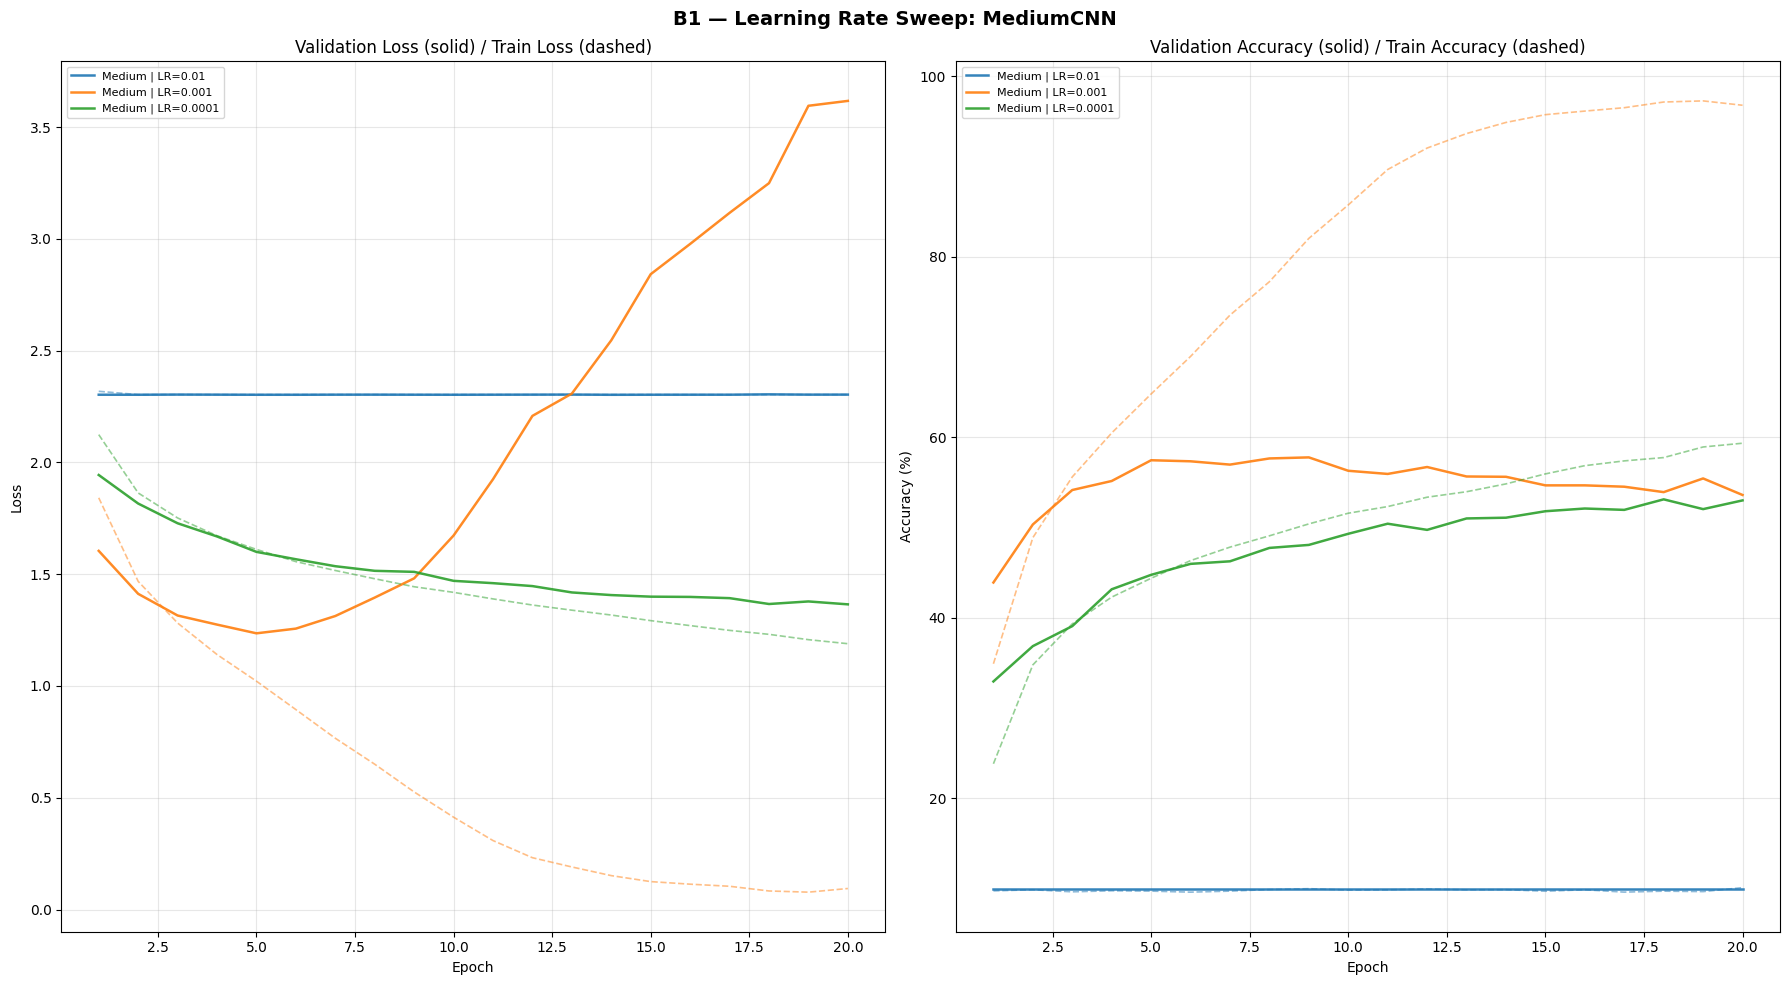

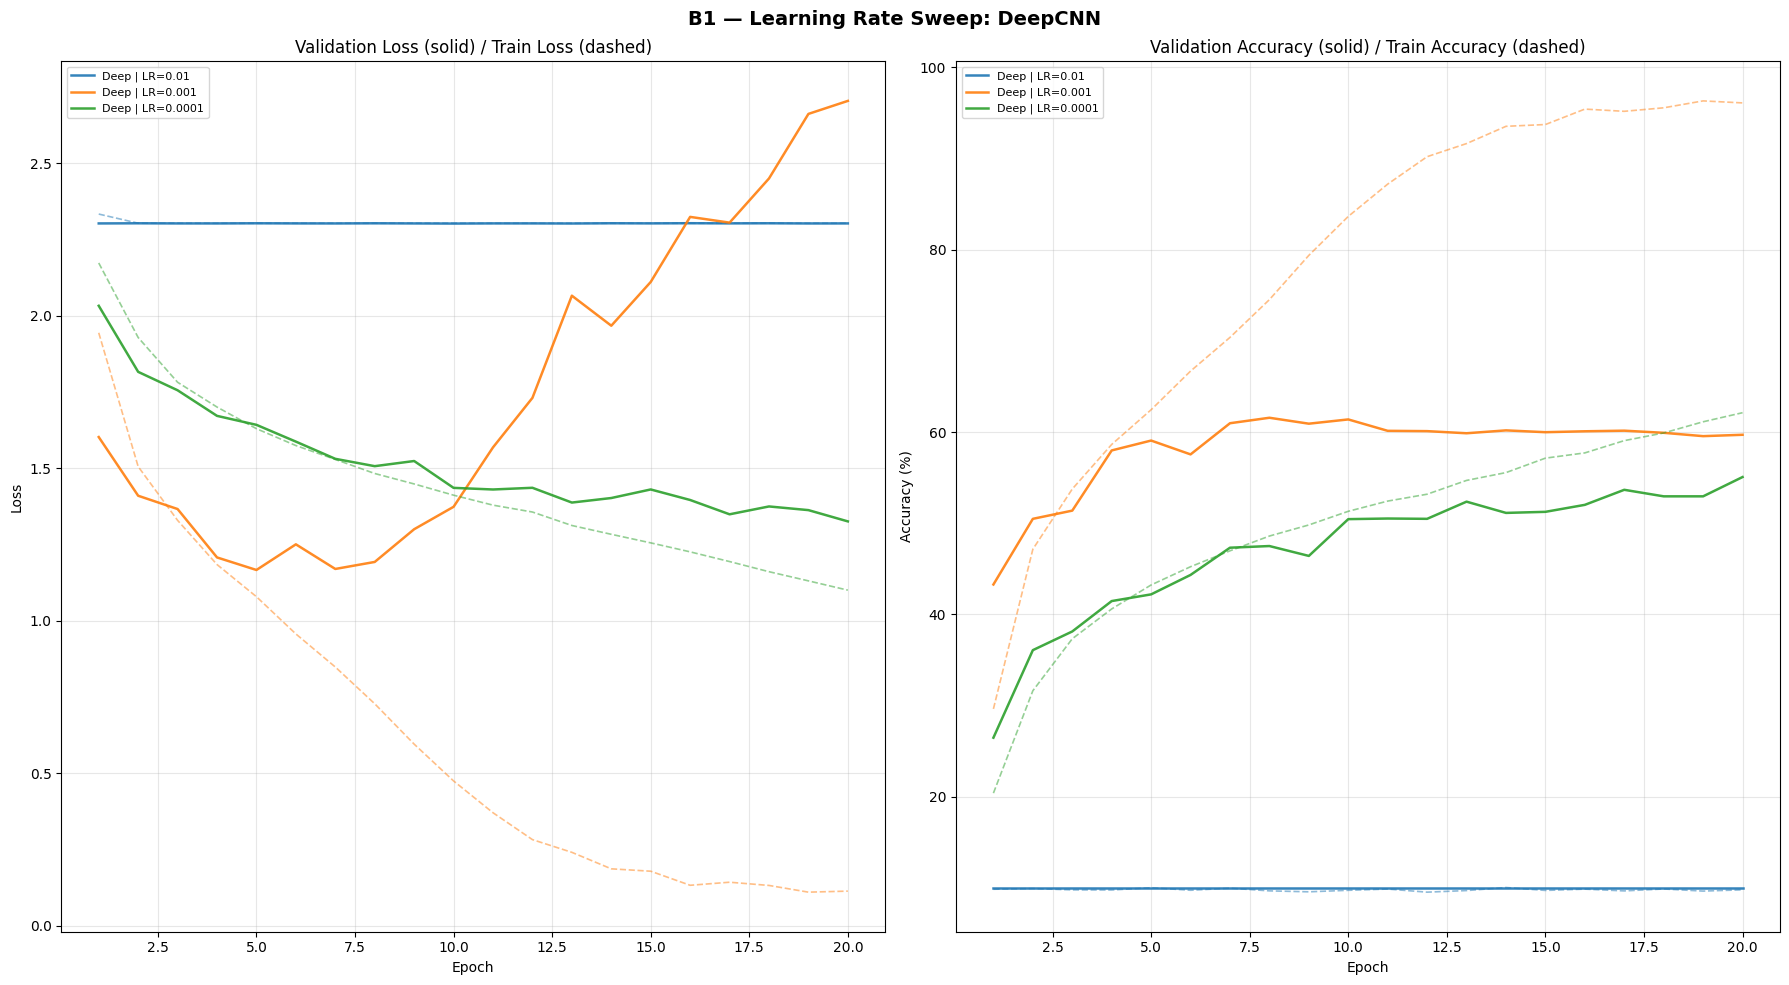

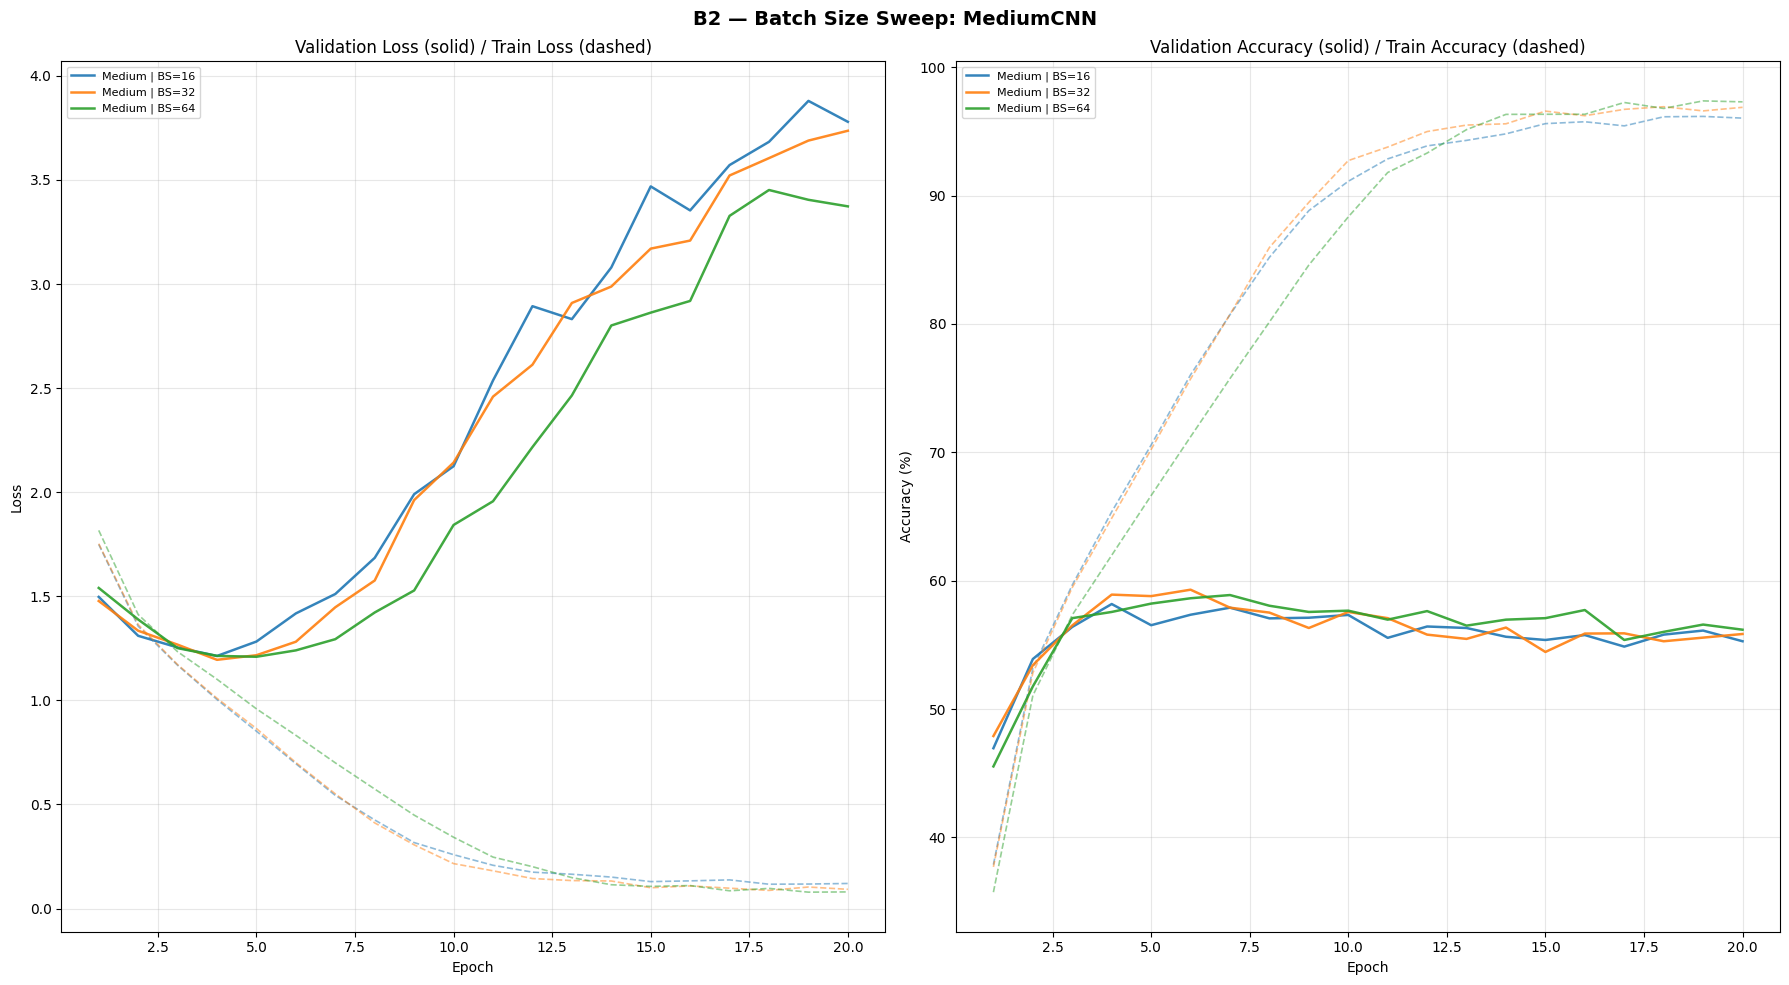

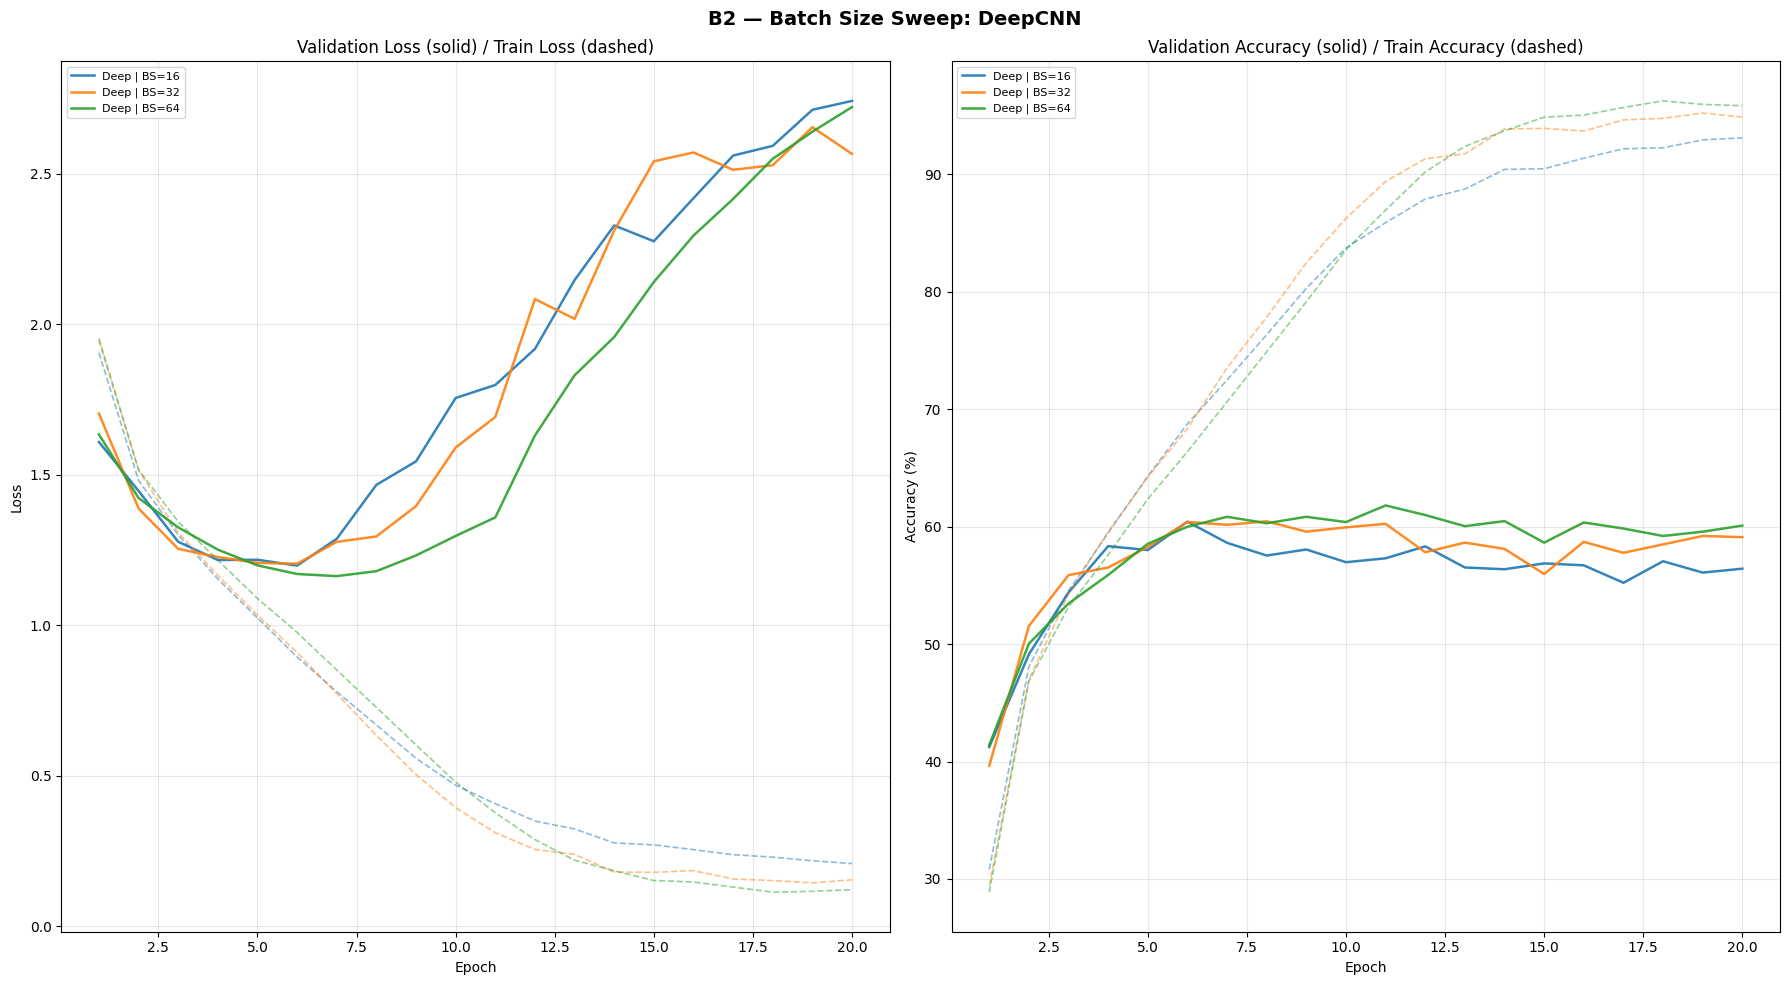

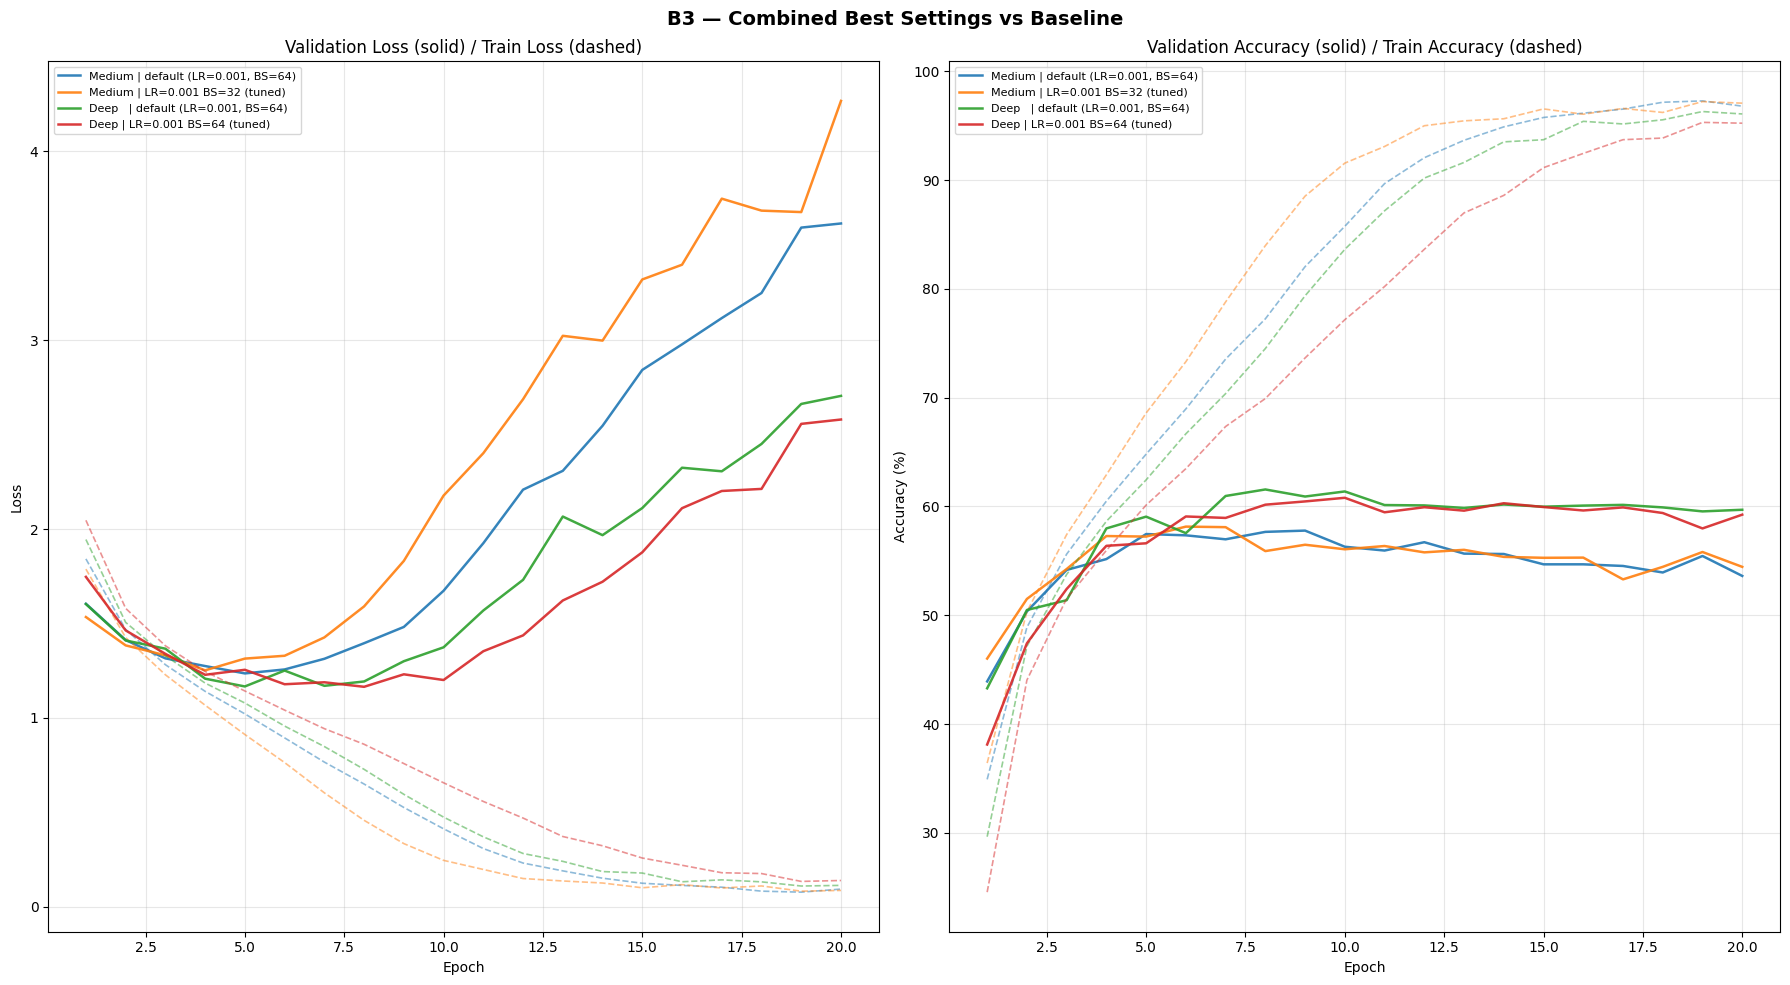

In [22]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def plot_hp_results(histories, labels, title, figsize=(18, 10)):
    """Plot train/val loss and accuracy for a set of runs."""
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    colors = plt.cm.tab10.colors
    
    for i, (history, label) in enumerate(zip(histories, labels)):
        color = colors[i % len(colors)]
        epochs = range(1, len(history['val_loss']) + 1)
        
        # Loss
        axes[0].plot(epochs, history['train_loss'], '--', color=color, alpha=0.5, linewidth=1.2)
        axes[0].plot(epochs, history['val_loss'],   '-',  color=color, alpha=0.9, linewidth=1.8, label=label)
        
        # Accuracy
        axes[1].plot(epochs, history['train_acc'], '--', color=color, alpha=0.5, linewidth=1.2)
        axes[1].plot(epochs, history['val_acc'],   '-',  color=color, alpha=0.9, linewidth=1.8, label=label)
    
    axes[0].set_title('Validation Loss (solid) / Train Loss (dashed)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)
    
    axes[1].set_title('Validation Accuracy (solid) / Train Accuracy (dashed)')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


# ── B1: Learning Rate Sweep ──────────────────────────────────────────────────
# Split by model for readability
medium_lr_idx = [i for i, l in enumerate(lr_labels) if 'Medium' in l]
deep_lr_idx   = [i for i, l in enumerate(lr_labels) if 'Deep'   in l]

plot_hp_results(
    [lr_histories[i] for i in medium_lr_idx],
    [lr_labels[i]    for i in medium_lr_idx],
    title='B1 — Learning Rate Sweep: MediumCNN'
)

plot_hp_results(
    [lr_histories[i] for i in deep_lr_idx],
    [lr_labels[i]    for i in deep_lr_idx],
    title='B1 — Learning Rate Sweep: DeepCNN'
)


# ── B2: Batch Size Sweep ─────────────────────────────────────────────────────
medium_bs_idx = [i for i, l in enumerate(bs_labels) if 'Medium' in l]
deep_bs_idx   = [i for i, l in enumerate(bs_labels) if 'Deep'   in l]

plot_hp_results(
    [bs_histories[i] for i in medium_bs_idx],
    [bs_labels[i]    for i in medium_bs_idx],
    title='B2 — Batch Size Sweep: MediumCNN'
)

plot_hp_results(
    [bs_histories[i] for i in deep_bs_idx],
    [bs_labels[i]    for i in deep_bs_idx],
    title='B2 — Batch Size Sweep: DeepCNN'
)


# ── B3: Combined Best vs Baseline ────────────────────────────────────────────
# Pull the default runs from B1 (LR=0.001, BS=64) for comparison
medium_baseline_idx = next(i for i, l in enumerate(lr_labels) if 'Medium' in l and 'LR=0.001' in l)
deep_baseline_idx   = next(i for i, l in enumerate(lr_labels) if 'Deep'   in l and 'LR=0.001' in l)

plot_hp_results(
    [lr_histories[medium_baseline_idx], combined_histories[0],
     lr_histories[deep_baseline_idx],   combined_histories[1]],
    ['Medium | default (LR=0.001, BS=64)', combined_labels[0],
     'Deep   | default (LR=0.001, BS=64)', combined_labels[1]],
    title='B3 — Combined Best Settings vs Baseline'
)

---
## Section 3: Overfitting vs Underfitting

In this section we will contrast the effects of overfitting and underfitting by comparing the deep network trained in the previous step with a less optimized version of the shallow network

In [26]:
model = ShallowCNN(num_classes=NUM_CLASSES, img_size=IMG_SIZE)

config = {
    'experiment': 'Underfitting',
    'model_name': "Shallow CNN Underfitting",
    'epochs': 20,
    'optimizer': 'sgd',
}

underfitting_history = train_model(model, train_loader, val_loader, config, wandb=False)

Epoch 1/20 | Train Loss: 2.2270, Acc: 18.35% | Val Loss: 2.1628, Acc: 24.58%
Epoch 2/20 | Train Loss: 2.1197, Acc: 26.24% | Val Loss: 2.0946, Acc: 27.47%
Epoch 3/20 | Train Loss: 2.0572, Acc: 29.06% | Val Loss: 2.0477, Acc: 30.07%
Epoch 4/20 | Train Loss: 2.0084, Acc: 31.27% | Val Loss: 2.0061, Acc: 31.27%
Epoch 5/20 | Train Loss: 1.9680, Acc: 32.86% | Val Loss: 1.9765, Acc: 32.33%
Epoch 6/20 | Train Loss: 1.9325, Acc: 34.10% | Val Loss: 1.9488, Acc: 33.63%
Epoch 7/20 | Train Loss: 1.9005, Acc: 35.54% | Val Loss: 1.9204, Acc: 34.55%
Epoch 8/20 | Train Loss: 1.8721, Acc: 36.20% | Val Loss: 1.8983, Acc: 34.98%
Epoch 9/20 | Train Loss: 1.8452, Acc: 37.30% | Val Loss: 1.8777, Acc: 35.92%
Epoch 10/20 | Train Loss: 1.8208, Acc: 38.17% | Val Loss: 1.8636, Acc: 36.57%
Epoch 11/20 | Train Loss: 1.7987, Acc: 39.01% | Val Loss: 1.8440, Acc: 37.02%
Epoch 12/20 | Train Loss: 1.7768, Acc: 39.96% | Val Loss: 1.8258, Acc: 37.40%
Epoch 13/20 | Train Loss: 1.7574, Acc: 40.38% | Val Loss: 1.8163, Acc: 38

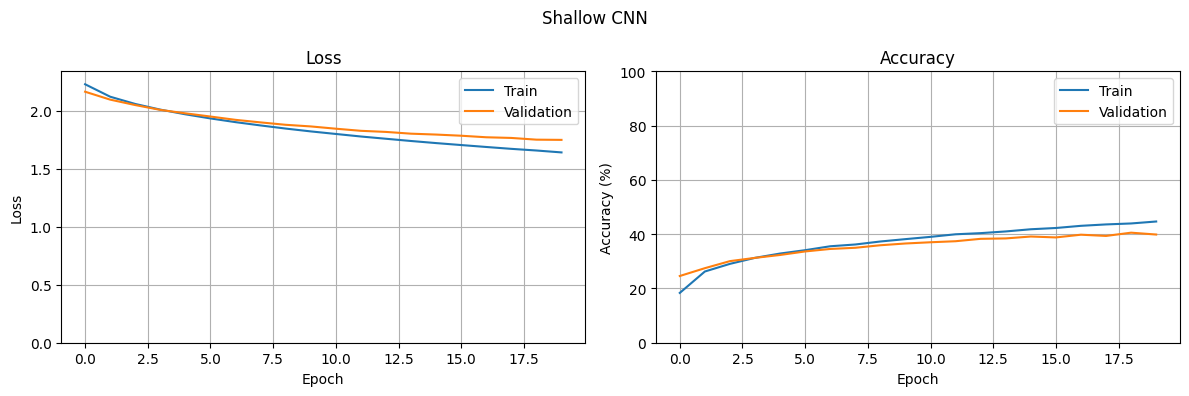

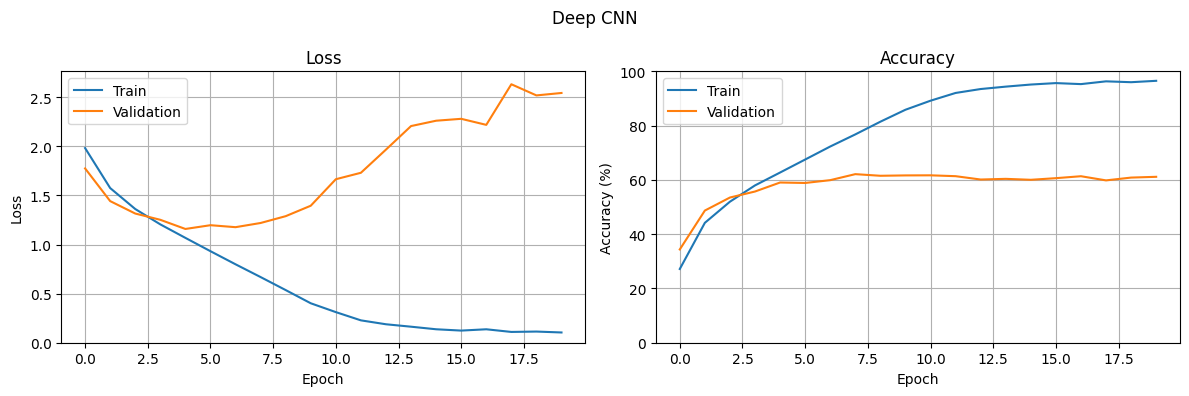

In [31]:
# Visualize overfitting and underfitting comparison
if "underfitting_history" not in globals():
    underfitting_history = load_history("Shallow CNN Underfitting")

plot_history(underfitting_history, title="Shallow CNN")
plot_history(depth_histories[2], title="Deep CNN")

### Overfitting and Underfitting Analysis

**YOUR OBSERVATIONS HERE:**

Explain how the deep network is complex enough to memorize the samples while the shallow network is too simple to even learn the training data

---
## Section 4: Regularization Techniques

In this section we will experiment with different regularization techniques such as L1, L2 and Dropout on the deep model

### Architectures

In [8]:
class MediumCNNRegularized(nn.Module):
    """3 convolutional layers with regularization."""
    def __init__(self, num_classes, dropout_conv, dropout_classifier):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(p=dropout_conv),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=dropout_classifier),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        return self.classifier(self.features(x))


class DeepCNNRegularized(nn.Module):
    """5 convolutional layers with regularization."""
    def __init__(self, num_classes, dropout_conv, dropout_classifier):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(p=dropout_conv),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(p=dropout_conv),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(p=dropout_conv),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=dropout_classifier),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        return self.classifier(self.features(x))

Train and Evaluate

In [9]:
train_loader, val_loader, _, _ = get_data_loaders(img_size=IMG_SIZE)

regularization_configs = [
    ("Medium CNN Batch Norm", 0.0, 0.0, 0.0, 0.0),
    ("Medium CNN L1 1e-4", 1e-4, 0.0, 0.0, 0.0),
    ("Medium CNN L2 1e-3", 0.0, 1e-3, 0.0, 0.0),
    ("Medium CNN Dropout 0.25 0.5", 0.0, 0.0, 0.25, 0.5),
]

regularization_histories = []
for name, l1_lambda, weight_decay, dropout_conv, dropout_classifier in regularization_configs:
    print(f"\n--- Training {name} ---")
    
    model = MediumCNNRegularized(num_classes=NUM_CLASSES, dropout_conv=dropout_conv, dropout_classifier=dropout_classifier)
    
    config = {
        'experiment': 'Regularization Comparison',
        'model_name': name,
        'epochs': 35,
        'lr': 0.002,
        'weight_decay': weight_decay,
        'l1_lambda': l1_lambda,
    }
    
    history = train_model(model, train_loader, val_loader, config, wandb=False)
    regularization_histories.append(history)


--- Training Medium CNN Dropout 0.25 0.5 ---
Epoch 1/35 | Train Loss: 2.0856, Acc: 24.38% | Val Loss: 1.9024, Acc: 31.80%
Epoch 2/35 | Train Loss: 1.8355, Acc: 34.08% | Val Loss: 1.7049, Acc: 38.25%
Epoch 3/35 | Train Loss: 1.7103, Acc: 39.22% | Val Loss: 1.5974, Acc: 42.95%
Epoch 4/35 | Train Loss: 1.6182, Acc: 42.84% | Val Loss: 1.4838, Acc: 47.52%
Epoch 5/35 | Train Loss: 1.5534, Acc: 45.42% | Val Loss: 1.4800, Acc: 47.05%
Epoch 6/35 | Train Loss: 1.4916, Acc: 47.23% | Val Loss: 1.3846, Acc: 51.32%
Epoch 7/35 | Train Loss: 1.4381, Acc: 50.02% | Val Loss: 1.3984, Acc: 50.43%
Epoch 8/35 | Train Loss: 1.3862, Acc: 51.70% | Val Loss: 1.3090, Acc: 53.42%
Epoch 9/35 | Train Loss: 1.3531, Acc: 53.01% | Val Loss: 1.2514, Acc: 55.77%
Epoch 10/35 | Train Loss: 1.3066, Acc: 54.59% | Val Loss: 1.3467, Acc: 53.25%
Epoch 11/35 | Train Loss: 1.2847, Acc: 55.59% | Val Loss: 1.2059, Acc: 57.42%
Epoch 12/35 | Train Loss: 1.2570, Acc: 56.36% | Val Loss: 1.2696, Acc: 55.25%
Epoch 13/35 | Train Loss: 1

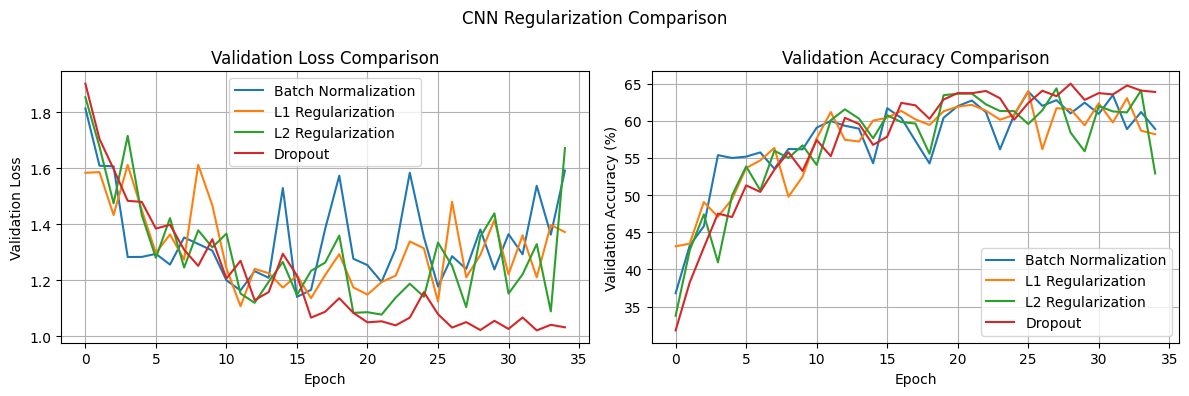


SUMMARY
Batch Normalization            | Best Val:  63.93% | Final Val:  58.90% | Best Train:  82.55% | Final Train:  82.55% | Final Gap:  23.65%
L1 Regularization              | Best Val:  64.00% | Final Val:  58.20% | Best Train:  79.77% | Final Train:  79.77% | Final Gap:  21.57%
L2 Regularization              | Best Val:  64.37% | Final Val:  52.92% | Best Train:  79.14% | Final Train:  79.14% | Final Gap:  26.23%
Dropout                        | Best Val:  65.00% | Final Val:  63.88% | Best Train:  66.41% | Final Train:  66.41% | Final Gap:   2.52%


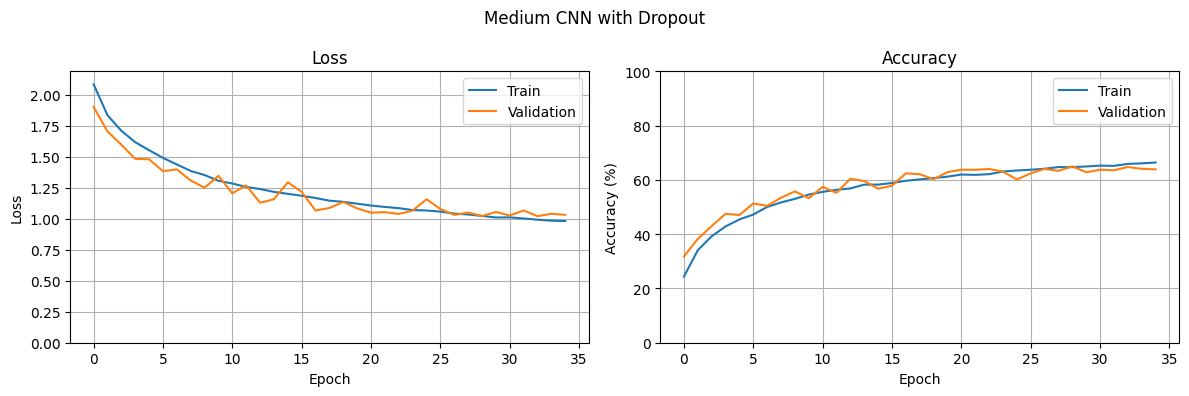

In [15]:
# Visualize regularization comparison
if "regularization_histories" not in globals():
    regularization_histories = [load_history("Medium CNN Batch Norm"), 
                               load_history("Medium CNN L1 1e-4"), 
                               load_history("Medium CNN L2 1e-3"),
                               load_history("Medium CNN Dropout 0.25 0.5")]

regularization_labels = ["Batch Normalization", "L1 Regularization", "L2 Regularization", "Dropout"]
compare_histories(regularization_histories, regularization_labels, "CNN Regularization Comparison")
summarize_histories(regularization_histories, regularization_labels)
plot_history(regularization_histories[-1], title="Medium CNN with Dropout")

In [12]:
train_loader, val_loader, _, _ = get_data_loaders(img_size=IMG_SIZE)

model = DeepCNNRegularized(num_classes=NUM_CLASSES, dropout_conv=0.25, dropout_classifier=0.5)

config = {
    'experiment': 'Regularization Comparison',
    'model_name': 'Deep CNN Dropout 0.25 0.5 + L2 1e-4',
    'epochs': 35,
    'lr': 0.002,
    'weight_decay': 1e-4
}

deep_regularization_history = train_model(model, train_loader, val_loader, config, wandb=False)

Epoch 1/35 | Train Loss: 1.8987, Acc: 32.25% | Val Loss: 1.6004, Acc: 43.38%
Epoch 2/35 | Train Loss: 1.5990, Acc: 43.80% | Val Loss: 1.4290, Acc: 49.20%
Epoch 3/35 | Train Loss: 1.4961, Acc: 48.02% | Val Loss: 1.3829, Acc: 52.12%
Epoch 4/35 | Train Loss: 1.4301, Acc: 50.40% | Val Loss: 1.3500, Acc: 52.08%
Epoch 5/35 | Train Loss: 1.3714, Acc: 52.68% | Val Loss: 1.1974, Acc: 58.50%
Epoch 6/35 | Train Loss: 1.3196, Acc: 54.50% | Val Loss: 1.1934, Acc: 58.85%
Epoch 7/35 | Train Loss: 1.2676, Acc: 56.33% | Val Loss: 1.1570, Acc: 58.87%
Epoch 8/35 | Train Loss: 1.2294, Acc: 57.87% | Val Loss: 1.1668, Acc: 59.50%
Epoch 9/35 | Train Loss: 1.1866, Acc: 59.33% | Val Loss: 1.0361, Acc: 64.08%
Epoch 10/35 | Train Loss: 1.1507, Acc: 60.50% | Val Loss: 1.0327, Acc: 63.82%
Epoch 11/35 | Train Loss: 1.1095, Acc: 62.17% | Val Loss: 0.9975, Acc: 64.67%
Epoch 12/35 | Train Loss: 1.0876, Acc: 62.91% | Val Loss: 1.0039, Acc: 65.48%
Epoch 13/35 | Train Loss: 1.0592, Acc: 63.82% | Val Loss: 0.9579, Acc: 66

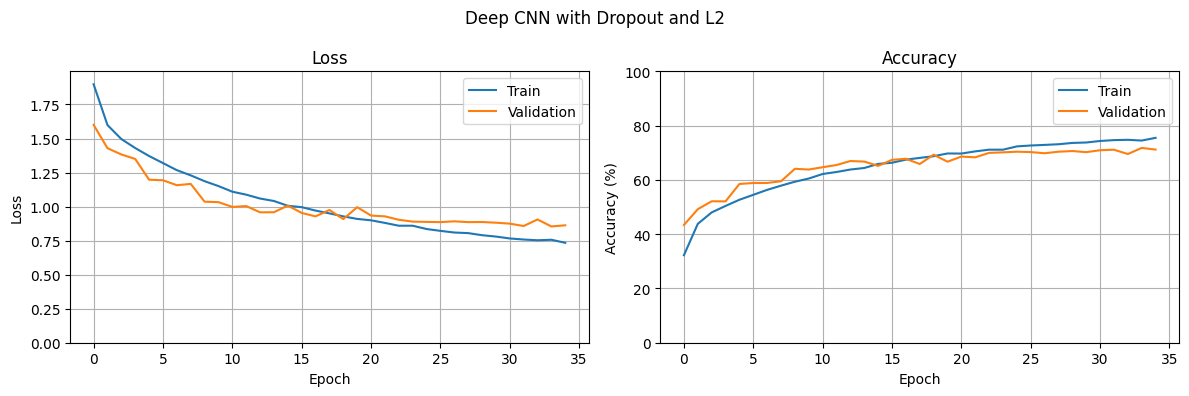


SUMMARY
Deep CNN with Dropout and L2   | Best Val:  71.78% | Final Val:  71.17% | Best Train:  75.49% | Final Train:  75.49% | Final Gap:   4.32%


In [17]:
if "deep_regularization_history" not in globals():
    deep_regularization_history = load_history("Deep CNN Dropout 0.25 0.5 + L2 1e-4")

plot_history(deep_regularization_history, title="Deep CNN with Dropout and L2")
summarize_histories([deep_regularization_history], ["Deep CNN with Dropout and L2"])

### Regularization Analysis

**YOUR OBSERVATIONS HERE:**

- No regularization: [largest gap, overfitting]
- Dropout: [reduces gap by randomly dropping neurons]
- Weight decay: [penalizes large weights, smoother decision boundary]
- Combined: [best generalization]

**Key Insight:** Regularization techniques help bridge the generalization gap...

---
## Section 5: Optimizer Comparison

In this section we will experiment with different optimization algorithms such as SGD, SGD with momentum, RMSprop and Adam.

In [ ]:
# Experiment E: Optimizer Comparison
print("="*60)
print("EXPERIMENT E: OPTIMIZER COMPARISON")
print("="*60)

train_loader, val_loader, _, _ = get_data_loaders(img_size=IMG_SIZE, batch_size=64)

optimizer_configs = [
    ('SGD', 'sgd', 0.01),
    ('SGD_Momentum', 'sgd_momentum', 0.01),
    ('RMSprop', 'rmsprop', 0.001),
    ('Adam', 'adam', 0.001),
]

opt_histories = []
opt_labels = []

In [ ]:
for name, opt_type, lr in optimizer_configs:
    print(f"\n--- {name} ---")
    model = MediumCNN(num_classes=NUM_CLASSES, img_size=IMG_SIZE)
    
    config = {
        'experiment': 'E_optimizers',
        'model_name': f'MediumCNN_{name}',
        'epochs': 20,
        'lr': lr,
        'optimizer': opt_type,
        'batch_size': 64,
        'img_size': IMG_SIZE
    }
    
    history = train_model(model, train_loader, val_loader, config)
    
    opt_histories.append(history)
    opt_labels.append(name)

In [ ]:
compare_histories(opt_histories, opt_labels, "Experiment E: Optimizer Comparison")

print("\n" + "="*60)
print("EXPERIMENT E: SUMMARY")
print("="*60)
for hist, label in zip(opt_histories, opt_labels):
    best_val = max(hist['val_acc'])
    print(f"{label:20} | Best Val Acc: {best_val:.2f}%")

### Optimizers Analysis

**YOUR OBSERVATIONS HERE:**

- **SGD**: [slow convergence, sensitive to LR]
- **SGD + Momentum**: [faster convergence, helps escape local minima]
- **RMSprop**: [adaptive LR, good for non-stationary problems]
- **Adam**: [combines momentum + adaptive LR, generally robust]

**Key Insight:** Adaptive optimizers like Adam often converge faster and are less sensitive to hyperparameters...

---
## Section 6: Data Augmentation

In this section we will experiment with different data augmentation techniques such as flip, rotation, and color jitter on the best model so far

In [22]:
train_loader, val_loader, _, _ = get_data_loaders(img_size=IMG_SIZE, augment=True)

model = DeepCNNRegularized(num_classes=NUM_CLASSES, dropout_conv=0.25, dropout_classifier=0.5)

config = {
    'experiment': 'Data Augmentation',
    'model_name': 'Deep CNN Dropout 0.25 0.5 + L2 1e-4 + Augmentation',
    'epochs': 50,
    'lr': 0.002,
    'weight_decay': 1e-4
}

augmentation_history = train_model(model, train_loader, val_loader, config, wandb=False)

Epoch 1/50 | Train Loss: 1.9631, Acc: 29.23% | Val Loss: 1.6366, Acc: 41.65%
Epoch 2/50 | Train Loss: 1.6591, Acc: 41.63% | Val Loss: 1.5213, Acc: 44.67%
Epoch 3/50 | Train Loss: 1.5640, Acc: 45.38% | Val Loss: 1.4405, Acc: 49.35%
Epoch 4/50 | Train Loss: 1.4927, Acc: 47.45% | Val Loss: 1.2742, Acc: 54.80%
Epoch 5/50 | Train Loss: 1.4265, Acc: 50.75% | Val Loss: 1.2279, Acc: 57.32%
Epoch 6/50 | Train Loss: 1.3846, Acc: 52.41% | Val Loss: 1.1823, Acc: 58.73%
Epoch 7/50 | Train Loss: 1.3446, Acc: 53.50% | Val Loss: 1.1636, Acc: 58.87%
Epoch 8/50 | Train Loss: 1.3182, Acc: 54.48% | Val Loss: 1.1026, Acc: 61.72%
Epoch 9/50 | Train Loss: 1.2791, Acc: 56.37% | Val Loss: 1.2620, Acc: 56.12%
Epoch 10/50 | Train Loss: 1.2514, Acc: 57.29% | Val Loss: 1.0903, Acc: 62.52%
Epoch 11/50 | Train Loss: 1.2286, Acc: 58.07% | Val Loss: 1.0650, Acc: 62.58%
Epoch 12/50 | Train Loss: 1.2080, Acc: 58.75% | Val Loss: 1.0404, Acc: 63.85%
Epoch 13/50 | Train Loss: 1.1781, Acc: 59.81% | Val Loss: 1.0272, Acc: 64

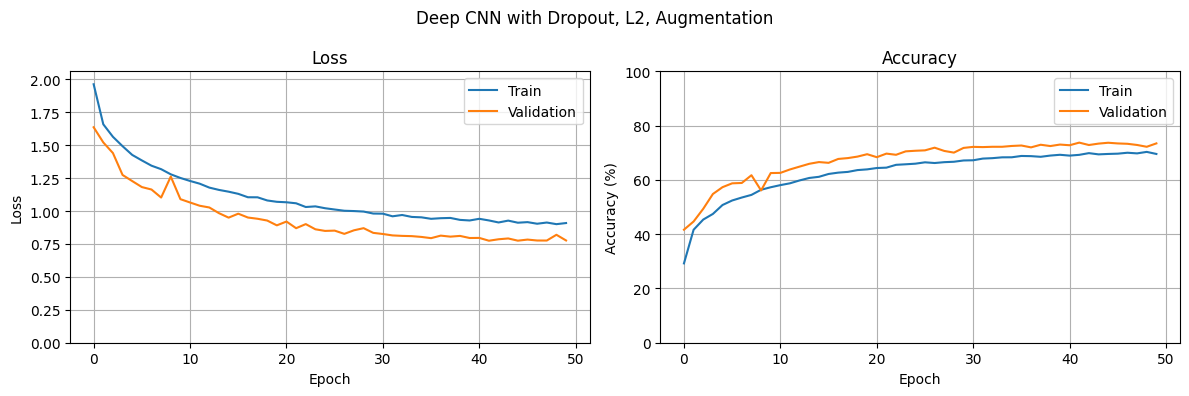


SUMMARY
Deep CNN with Dropout, L2, Augmentation | Best Val:  73.73% | Final Val:  73.45% | Best Train:  70.32% | Final Train:  69.55% | Final Gap:  -3.90%


In [5]:
if "augmentation_history" not in globals():
    augmentation_history = load_history("Deep CNN Dropout 0.25 0.5 + L2 1e-4 + Augmentation")

plot_history(augmentation_history, title="Deep CNN with Dropout, L2, Augmentation")
summarize_histories([augmentation_history], ["Deep CNN with Dropout, L2, Augmentation"])

### Data Augmentation Analysis

**YOUR OBSERVATIONS HERE:**

- Augmentation creates artificial variety in training data
- Model sees different perspectives (flips, rotations) of same images
- Reduces overfitting by increasing effective dataset size
- Training loss may be higher, but validation accuracy improves

---
## Section 7: Error Analysis

In this section we will perform error analysis to identify common misclassifications on the best model so far by using the confusion matrix and visualizing misclassified samples

In [ ]:
# Error Analysis Functions
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def get_predictions(model, loader, device):
    """Get all predictions and labels from a data loader."""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = outputs.max(1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)


def plot_confusion_matrix(y_true, y_pred, class_names):
    """Plot confusion matrix as a heatmap."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()
    return cm


def get_misclassified_samples(dataset, preds, labels, n=5):
    """Get indices and info of misclassified samples."""
    misclassified = []
    for idx in range(len(preds)):
        if preds[idx] != labels[idx]:
            misclassified.append({
                'idx': idx,
                'true_label': labels[idx],
                'pred_label': preds[idx]
            })
    return misclassified[:n*10]  # Return more than needed for variety


def show_misclassified(dataset, misclassified_info, class_names, n=10):
    """Visualize misclassified samples."""
    n = min(n, len(misclassified_info))
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    
    for i, info in enumerate(misclassified_info[:n]):
        img, _ = dataset[info['idx']]
        img = img.permute(1, 2, 0).numpy()
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)
        
        axes[i].imshow(img)
        axes[i].set_title(f"True: {class_names[info['true_label']]}\nPred: {class_names[info['pred_label']]}", 
                         fontsize=9)
        axes[i].axis('off')
    
    plt.suptitle('Misclassified Samples', fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
# Run Error Analysis
print("="*60)
print("OPTIONAL F: ERROR ANALYSIS")
print("="*60)

# Train a model for error analysis (or use existing trained model)
train_loader, val_loader, train_dataset, val_dataset = get_data_loaders(img_size=IMG_SIZE)

print("\n--- Training model for error analysis ---")
model_for_analysis = DeepCNN(num_classes=NUM_CLASSES, img_size=IMG_SIZE)

config = {
    'experiment': 'F_error_analysis',
    'model_name': 'DeepCNN_for_analysis',
    'epochs': 20,
    'lr': 0.001,
    'optimizer': 'adam',
    'batch_size': BATCH_SIZE,
    'img_size': IMG_SIZE
}

history = train_model(model_for_analysis, train_loader, val_loader, config)

# Get predictions
print("\n--- Getting predictions on validation set ---")
preds, labels, probs = get_predictions(model_for_analysis, val_loader, device)

In [ ]:
# Plot confusion matrix
print("\n--- Confusion Matrix ---")
cm = plot_confusion_matrix(labels, preds, CLASS_NAMES)

# Print classification report
print("\n--- Classification Report ---")
print(classification_report(labels, preds, target_names=CLASS_NAMES))

# Calculate per-class accuracy
print("\n--- Per-Class Accuracy ---")
for i, class_name in enumerate(CLASS_NAMES):
    class_mask = labels == i
    class_acc = (preds[class_mask] == labels[class_mask]).mean() * 100
    print(f"{class_name:12}: {class_acc:.1f}%")

In [ ]:
# Visualize misclassified samples
print("\n--- Misclassified Samples ---")
misclassified = get_misclassified_samples(val_dataset, preds, labels)
print(f"Total misclassified: {len([m for m in range(len(preds)) if preds[m] != labels[m]])} out of {len(preds)}")

show_misclassified(val_dataset, misclassified, CLASS_NAMES, n=10)

# Analyze most common confusions
print("\n--- Most Common Confusions ---")
confusion_pairs = {}
for m in misclassified:
    pair = (CLASS_NAMES[m['true_label']], CLASS_NAMES[m['pred_label']])
    confusion_pairs[pair] = confusion_pairs.get(pair, 0) + 1

sorted_pairs = sorted(confusion_pairs.items(), key=lambda x: x[1], reverse=True)[:10]
for (true_cls, pred_cls), count in sorted_pairs:
    print(f"  {true_cls:10} -> {pred_cls:10}: {count} times")

### Error Analysis: Observations

**YOUR OBSERVATIONS HERE:**

**Common Confusion Patterns:**
- [Which classes are often confused with each other?]
- [Are there any patterns (e.g., similar-looking animals)?]

**Potential Reasons for Misclassifications:**
- Similar visual features (e.g., four-legged animals)
- Image quality issues
- Unusual poses or backgrounds
- Potential mislabeling in dataset

**Suggestions for Improvement:**
- More training data for confused classes
- Data augmentation targeting weak points
- Class-weighted loss function

---
## Section 8: ResNet Comparison

In this section we will fine-tine ResNet on our data and compare it with our results so far

In [ ]:
from torchvision import models

def get_resnet18(num_classes, pretrained=True):
    """Get ResNet18 model, optionally pretrained."""
    if pretrained:
        # Load pretrained weights
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        # Freeze early layers (optional - comment out for full fine-tuning)
        for param in list(model.parameters())[:-20]:
            param.requires_grad = False
    else:
        model = models.resnet18(weights=None)
    
    # Replace final layer for our number of classes
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    
    return model


def count_parameters(model):
    """Count trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
# ResNet Comparison Experiment
print("="*60)
print("OPTIONAL G: RESNET COMPARISON")
print("="*60)

# Use slightly larger images for ResNet (it expects 224, but 128 works well too)
RESNET_IMG_SIZE = 128  # Balance between speed and performance

train_loader, val_loader, _, _ = get_data_loaders(img_size=RESNET_IMG_SIZE)

resnet_histories = []
resnet_labels = []

# Compare model sizes
print("\n--- Model Parameters ---")
deep_cnn = DeepCNN(num_classes=NUM_CLASSES, img_size=RESNET_IMG_SIZE)
resnet_pretrained = get_resnet18(NUM_CLASSES, pretrained=True)
resnet_scratch = get_resnet18(NUM_CLASSES, pretrained=False)

print(f"DeepCNN:              {count_parameters(deep_cnn):,} trainable params")
print(f"ResNet18 (pretrained): {count_parameters(resnet_pretrained):,} trainable params")
print(f"ResNet18 (scratch):    {count_parameters(resnet_scratch):,} trainable params")

In [ ]:
# Train our DeepCNN for comparison
print("\n--- Training DeepCNN ---")
model = DeepCNN(num_classes=NUM_CLASSES, img_size=RESNET_IMG_SIZE)

config = {
    'experiment': 'G_resnet_comparison',
    'model_name': 'DeepCNN_baseline',
    'epochs': 15,
    'lr': 0.001,
    'optimizer': 'adam',
    'batch_size': BATCH_SIZE,
    'img_size': RESNET_IMG_SIZE,
    'architecture': 'custom_deep_cnn'
}

history = train_model(model, train_loader, val_loader, config)
resnet_histories.append(history)
resnet_labels.append("DeepCNN (ours)")

In [ ]:
# Train ResNet18 with pretrained weights (Transfer Learning)
print("\n--- Training ResNet18 (Pretrained / Transfer Learning) ---")
model = get_resnet18(NUM_CLASSES, pretrained=True)

config = {
    'experiment': 'G_resnet_comparison',
    'model_name': 'ResNet18_pretrained',
    'epochs': 15,
    'lr': 0.001,
    'optimizer': 'adam',
    'batch_size': BATCH_SIZE,
    'img_size': RESNET_IMG_SIZE,
    'architecture': 'resnet18',
    'pretrained': True,
    'transfer_learning': True
}

history = train_model(model, train_loader, val_loader, config)
resnet_histories.append(history)
resnet_labels.append("ResNet18 (pretrained)")

In [ ]:
# Compare all architectures
compare_histories(resnet_histories, resnet_labels, "ResNet vs Custom CNN Comparison")

print("\n" + "="*60)
print("RESNET COMPARISON: SUMMARY")
print("="*60)
for hist, label in zip(resnet_histories, resnet_labels):
    best_val = max(hist['val_acc'])
    final_val = hist['val_acc'][-1]
    print(f"{label:25} | Best Val: {best_val:.2f}% | Final Val: {final_val:.2f}%")

### ResNet Comparison: Analysis

**YOUR OBSERVATIONS HERE:**

**DeepCNN (Custom):**
- [Performance, training time, simplicity]

**ResNet18 (Pretrained / Transfer Learning):**
- [Should achieve best performance due to pretrained features]
- [Faster convergence expected]
- [Benefits from ImageNet knowledge]

**Key Insights:**
- Transfer learning significantly accelerates training
- Pretrained models have learned general features (edges, textures) useful for many tasks
- For limited data, transfer learning often outperforms training from scratch

In [ ]:
compare_histories(aug_histories, aug_labels, "Data Augmentation Comparison")

print("\nSUMMARY:")
for hist, label in zip(aug_histories, aug_labels):
    best_val = max(hist['val_acc'])
    print(f"{label:20} | Best Val Acc: {best_val:.2f}%")

---
## Section 9: Conclusions

### W&B Dashboard

All experiments are logged to Weights & Biases. View interactive plots and compare runs at:

**https://wandb.ai/YOUR_USERNAME/icosimal-cnn**

(Include screenshots from your W&B dashboard here)

### Key Conclusions

1. **Depth matters**: Deeper CNNs can learn hierarchical features but need proper regularization

2. **Hyperparameters are critical**: Wrong learning rate can prevent convergence entirely

3. **Overfitting vs Underfitting**: Understanding the trade-off helps model selection

4. **Regularization**: Essential for preventing overfitting, especially with limited data

5. **Optimizer choice**: Adaptive methods (Adam) are generally more robust

### Best Model Configuration

Based on experiments, the recommended configuration is:
- Architecture: [DeepCNN / MediumCNN]
- Optimizer: Adam, LR=0.001
- Regularization: Dropout=0.3, Weight Decay=1e-4
- Data Augmentation: Yes (horizontal flip, rotation, color jitter)
- Image Size: [64x64 for quick experiments / 224x224 for final]

---
## Appendix: Best Model at Full Resolution

This appendix includes a run of the best configuration presented above with the original image resolution.